In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from tensorflow import keras
from keras import layers

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\SuNi\Downloads\Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df = df.drop(['CustomerID'], axis=1)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 7.4 KB


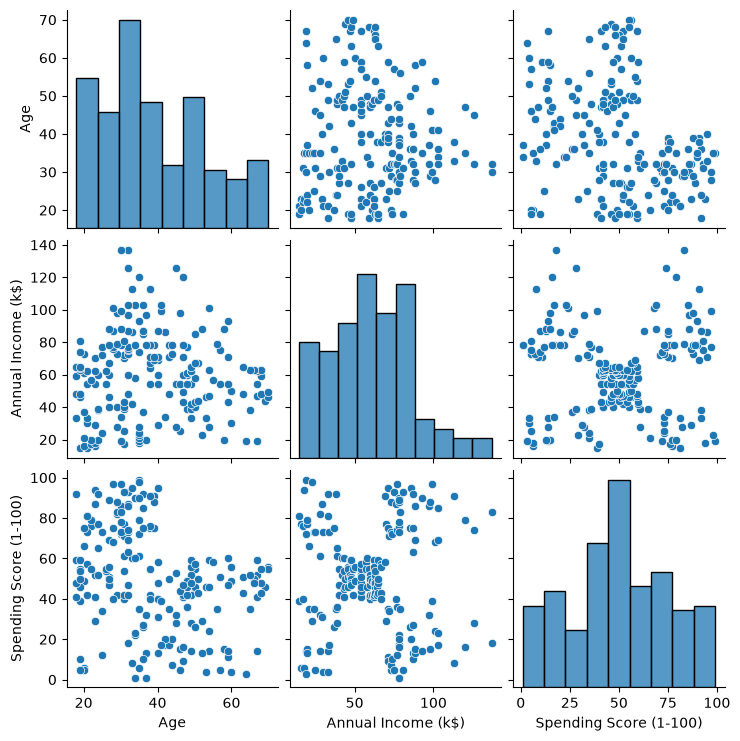

In [4]:
sns.pairplot(df)

In [28]:
word_cols = ['Gender']
le = LabelEncoder()
for col in word_cols:
    df[col] = le.fit_transform(df[col].astype(str))

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Annual Income (k$)', 'Spending Score (1-100)']])

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,2
3,0,23,16,77,2
4,0,31,17,40,2


In [29]:
df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000,1.425000
std,0.497633,13.969007,26.264721,25.823522,0.792157
min,0.000000,18.000000,15.000000,1.000000,0.000000
25%,0.000000,28.750000,41.500000,34.750000,1.000000
50%,0.000000,36.000000,61.500000,50.000000,2.000000
75%,1.000000,49.000000,78.000000,73.000000,2.000000
max,1.000000,70.000000,137.000000,99.000000,2.000000


In [30]:
df.isnull().any()

Gender                    False
Age                       False
Annual Income (k$)        False
Spending Score (1-100)    False
Cluster                   False
dtype: bool

In [31]:
X = df.drop(['Gender', 'Cluster'], axis=1)
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
print('\n--- Training 2D Convolutional Neural Network (CNN) ---')

num_classes = len(np.unique(y))

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1, 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1, 1)

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1], 1, 1)),
    layers.Conv2D(32, kernel_size=(3, 1),activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 1)),
    layers.Conv2D(16, kernel_size=(3, 1),activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_cnn, y_train,
    epochs = 50,
    batch_size = 16,
    validation_split = 0.1,
    verbose = 1
)

loss, accuracy = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


--- Training 2D Convolutional Neural Network (CNN) ---
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.4444 - loss: 1.0820 - val_accuracy: 0.8750 - val_loss: 1.0354
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7778 - loss: 1.0341 - val_accuracy: 1.0000 - val_loss: 0.9829
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8264 - loss: 0.9816 - val_accuracy: 0.9375 - val_loss: 0.9226
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8125 - loss: 0.9255 - val_accuracy: 0.9375 - val_loss: 0.8598
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8264 - loss: 0.8618 - val_accuracy: 0.9375 - val_loss: 0.7934
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8264 - loss: 0.7949 - val_accuracy: 0.9375 - val_loss: 0.7170
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8264 - loss: 0.7217 - val_accuracy: 0.9375 - val_loss: 0.6385
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8264 -

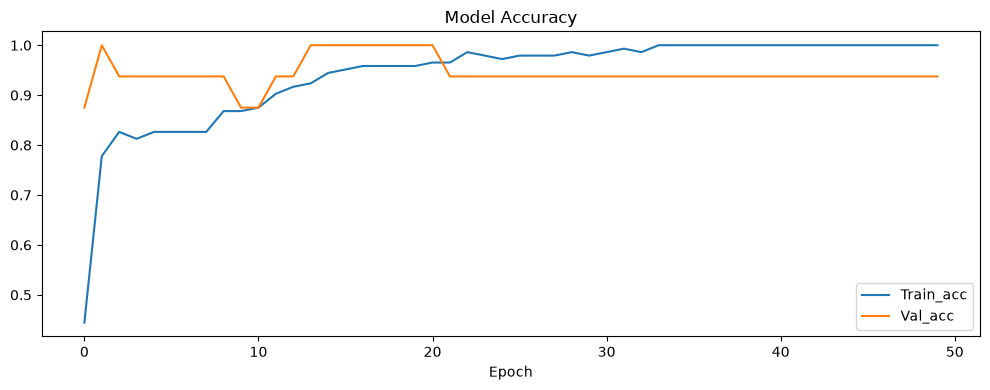

In [42]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train_acc')
plt.plot(history.history['val_accuracy'], label='Val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

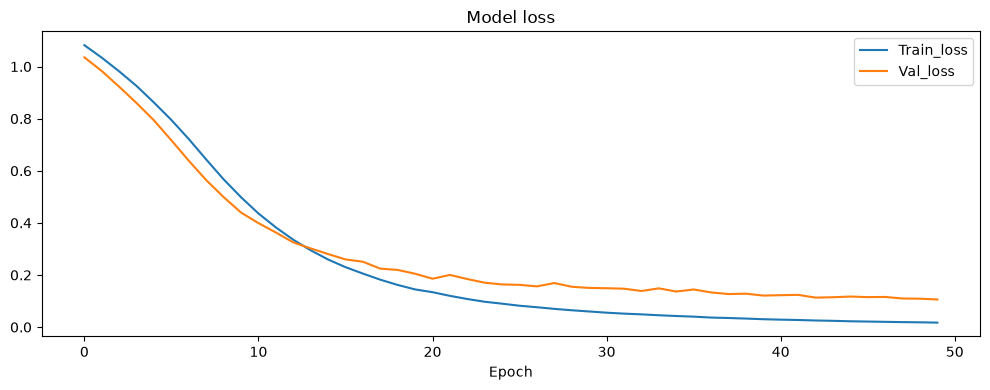

In [43]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train_loss')
plt.plot(history.history['val_loss'], label='Val_loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()